In [28]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data_set=load_dataset('lukebarousse/data_jobs')
df = data_set['train'].to_pandas()
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
import ast
def clean_list(x):
    if pd.notna(x):
        return ast.literal_eval(x)
df['job_skills']=df['job_skills'].apply(clean_list)
df = df.drop_duplicates(subset=['job_title', 'job_location', 'job_via'])
df['job_id'] = df.index


KeyboardInterrupt: 

In [ ]:
df_us_da=df[(df['job_country']=='United States') & (df['job_title_short']=='Data Analyst')].copy()

In [ ]:
df_us_explode=df_us_da.explode('job_skills')

In [30]:
df_us_explode['job_posted_month_no']=df_us_explode['job_posted_date'].dt.month
df_us_da['job_posted_month_no']=df_us_da['job_posted_date'].dt.month

In [ ]:
df_us_pivot=df_us_explode.pivot_table(index='job_posted_month_no',columns='job_skills',aggfunc='size',fill_value=0)

In [ ]:
df_us_pivot.loc['Total']=df_us_pivot.sum()

df_us_pivot=df_us_pivot[df_us_pivot.loc['Total'].sort_values(ascending=False).index]

df_us_pivot=df_us_pivot.drop('Total')

In [46]:
DA_total=df_us_da.groupby('job_posted_month_no').size()

df_us_percent=df_us_pivot.div(DA_total/100,axis=0)


In [47]:
df_us_percent = df_us_percent.reset_index()
df_us_percent['job_posted_month'] = pd.to_datetime(
    df_us_percent['job_posted_month_no'], 
    format='%m'
).dt.strftime('%b') 
df_us_percent = df_us_percent.set_index('job_posted_month')
df_us_percent = df_us_percent.drop(columns='job_posted_month_no')


In [49]:
df_us_percent 


job_skills,sql,excel,tableau,python,sas,power bi,r,word,powerpoint,oracle,...,ionic,microsoft lists,next.js,google chat,capacitor,fastapi,qt,couchdb,codecommit,msaccess
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,52.314383,42.249146,28.393911,25.566946,21.310966,15.206586,17.458838,11.773843,11.416589,8.014911,...,0.00000,0.000000,0.000000,0.000000,0.015533,0.000000,0.000000,0.00000,0.015533,0.000000
Feb,50.352990,42.441860,26.142027,25.207641,19.808970,17.462625,16.465947,12.396179,11.897841,8.450997,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
Mar,50.722789,43.409864,28.295068,26.551871,19.642857,16.602891,18.622449,12.329932,11.054422,6.611395,...,0.00000,0.000000,0.000000,0.021259,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
Apr,51.173403,42.025206,28.031291,26.401565,21.816601,17.122990,16.297262,11.647110,11.016949,7.214255,...,0.02173,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.02173,0.000000,0.000000
May,49.193548,42.688172,27.500000,26.236559,18.064516,16.209677,16.102151,11.935484,10.107527,7.069892,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.026882
Jun,48.502172,41.939172,27.463984,27.143837,16.053053,16.761948,16.784816,13.126000,11.273725,7.088955,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.022868,0.00000,0.000000,0.000000
Jul,48.882752,40.873713,29.249310,26.914386,18.729601,16.670851,15.716796,11.674617,10.946523,8.134572,...,0.00000,0.000000,0.025107,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
Aug,49.833039,41.642114,28.186997,29.365547,19.367511,18.424671,18.130033,12.217639,12.021214,7.307012,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
Sep,47.640835,39.004861,28.109808,25.164427,18.472977,17.100372,15.127252,10.895053,10.780669,7.749500,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000


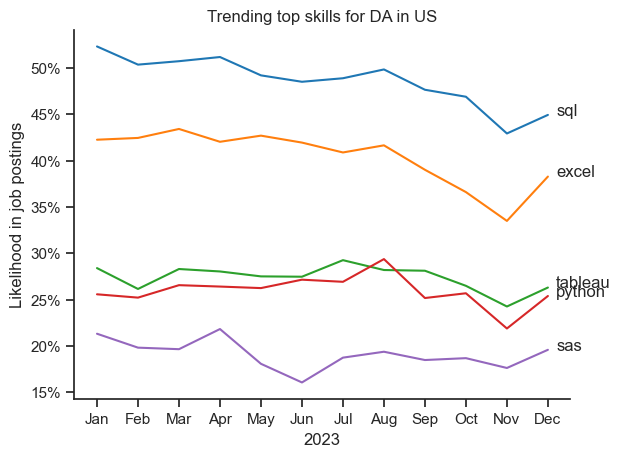

In [ ]:
df_plot=df_us_percent.iloc[:,:5]

sns.lineplot(data=df_plot,dashes=False,palette='tab10')
sns.set_theme(style='ticks')
plt.legend().remove()
plt.title('Trending top skills for DA in US')
plt.xlabel('2023')
plt.ylabel('Likelihood in job postings')
sns.despine()

from matplotlib.ticker import PercentFormatter
ax=plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
for i in range(5):
    plt.text(11.2,df_plot.iloc[-1,i], df_plot.columns[i])
